In [1]:
#import and formatting 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
import numpy as np
from itertools import combinations

plt.rcParams['pdf.fonttype'] = 42

df = pd.read_excel("Source_Data_CXCL12_placenta.xlsx", sheet_name = "Extended_Fig_4H")

DECIDUA ANALYSIS

Decidua - Kruskal-Wallis Test:
H-statistic: 11.4833
P-value: 0.1189


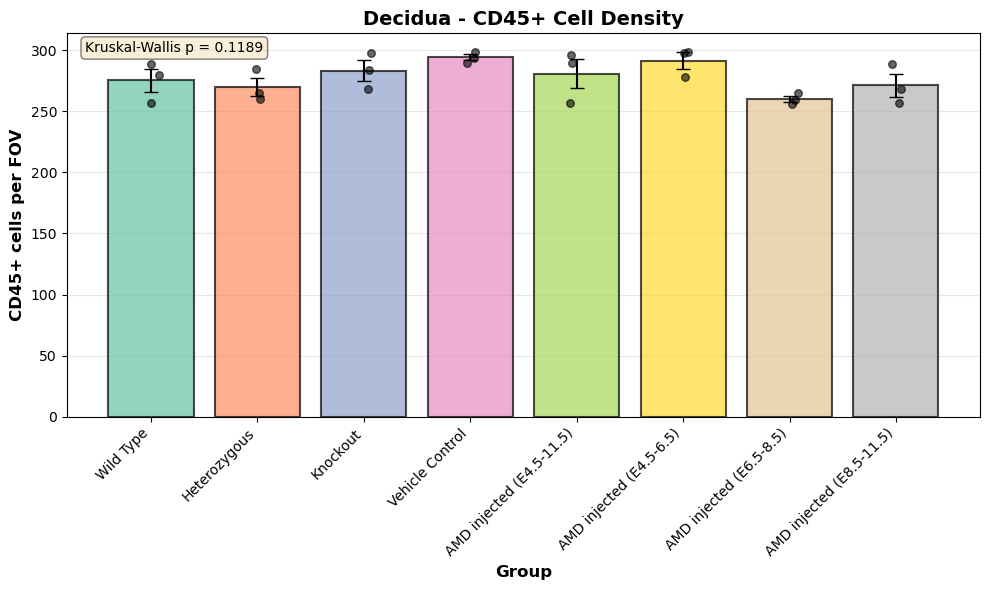


PLACENTA ANALYSIS

Placenta - Kruskal-Wallis Test:
H-statistic: 14.6619
P-value: 0.0406

Placenta - Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):
Number of comparisons: 28
Bonferroni-corrected alpha: 0.0018

Wild Type vs Heterozygous: p = 0.1000 ns
Wild Type vs Knockout: p = 0.2683 ns
Wild Type vs Vehicle Control: p = 0.1000 ns
Wild Type vs AMD injected (E4.5-11.5): p = 0.1000 ns
Wild Type vs AMD injected (E4.5-6.5): p = 1.0000 ns
Wild Type vs AMD injected (E6.5-8.5): p = 1.0000 ns
Wild Type vs AMD injected (E8.5-11.5): p = 0.4000 ns
Heterozygous vs Knockout: p = 0.7000 ns
Heterozygous vs Vehicle Control: p = 0.1000 ns
Heterozygous vs AMD injected (E4.5-11.5): p = 0.1000 ns
Heterozygous vs AMD injected (E4.5-6.5): p = 0.7000 ns
Heterozygous vs AMD injected (E6.5-8.5): p = 0.2000 ns
Heterozygous vs AMD injected (E8.5-11.5): p = 1.0000 ns
Knockout vs Vehicle Control: p = 0.1000 ns
Knockout vs AMD injected (E4.5-11.5): p = 0.1000 ns
Knockout vs AMD injected (

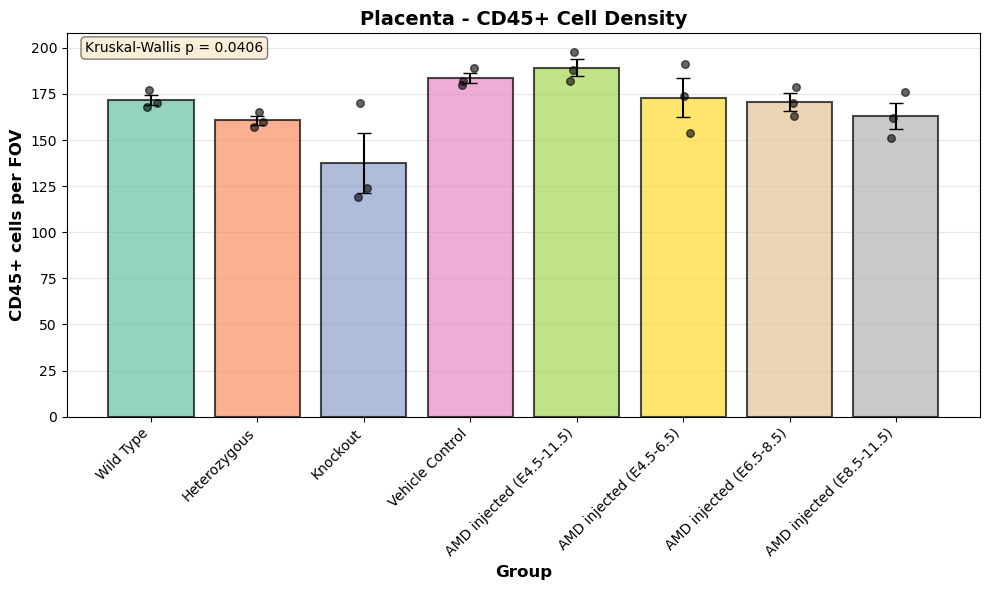

In [2]:
decidua_data = df[df.iloc[:, 0].str.lower() == 'decidua'].copy()
placenta_data = df[df.iloc[:, 0].str.lower() == 'placenta'].copy()

def add_significance_bars(ax, pairs, y_data, group_positions):
    """
    Add significance bars to the plot
    """
    if not pairs:
        return
    
    y_max = max([max(y) for y in y_data if len(y) > 0])
    y_range = y_max - min([min(y) for y in y_data if len(y) > 0])
    
    bar_height = y_max + y_range * 0.05
    height_increment = y_range * 0.08
    
    for idx, (group1, group2, p_val) in enumerate(pairs):
        x1 = list(group_positions.keys()).index(group1)
        x2 = list(group_positions.keys()).index(group2)
        
        level = idx
        y = bar_height + (level * height_increment)
        
        ax.plot([x1, x1, x2, x2], [y, y + height_increment*0.2, y + height_increment*0.2, y], 
                linewidth=1.5, color='black')
        
        if p_val < 0.001:
            sig_symbol = '***'
        elif p_val < 0.01:
            sig_symbol = '**'
        elif p_val < 0.05:
            sig_symbol = '*'
        else:
            sig_symbol = 'ns'
        
        ax.text((x1 + x2) / 2, y + height_increment*0.2, sig_symbol,
                ha='center', va='bottom', fontsize=10, fontweight='bold')

def process_and_plot(data, tissue_type):
    """
    Process data and create bar plot with statistical analysis
    """
    data_cols = data.iloc[:, 1:]
    
    melted_data = []
    for col in data_cols.columns:
        for value in data_cols[col].dropna():
            melted_data.append({'Group': col, 'Count': value})
    
    plot_df = pd.DataFrame(melted_data)
    
    groups = plot_df['Group'].unique()
    group_data = [plot_df[plot_df['Group'] == group]['Count'].values for group in groups]
    
    groups = [groups[i] for i in range(len(groups)) if len(group_data[i]) > 0]
    group_data = [g for g in group_data if len(g) > 0]
    
    group_means = [np.mean(g) for g in group_data]
    group_sems = [stats.sem(g) for g in group_data]
    
    significant_pairs = []
    
    if len(groups) > 1:
        h_stat, p_value = kruskal(*group_data)
        print(f"\n{tissue_type} - Kruskal-Wallis Test:")
        print(f"H-statistic: {h_stat:.4f}")
        print(f"P-value: {p_value:.4f}")
        
        if p_value < 0.05:
            print(f"\n{tissue_type} - Post-hoc pairwise comparisons (Mann-Whitney U with Bonferroni correction):")
            pairs = list(combinations(range(len(groups)), 2))
            n_comparisons = len(pairs)
            bonferroni_alpha = 0.05 / n_comparisons
            
            print(f"Number of comparisons: {n_comparisons}")
            print(f"Bonferroni-corrected alpha: {bonferroni_alpha:.4f}\n")
            
            for i, j in pairs:
                stat, p = stats.mannwhitneyu(group_data[i], group_data[j], alternative='two-sided')
                is_sig = p < bonferroni_alpha
                if is_sig:
                    significant_pairs.append((groups[i], groups[j], p))
                print(f"{groups[i]} vs {groups[j]}: p = {p:.4f} {'*' if is_sig else 'ns'}")
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x_pos = np.arange(len(groups))
    
    bars = ax.bar(x_pos, group_means, yerr=group_sems, 
                   capsize=5, alpha=0.7, 
                   color=sns.color_palette('Set2', len(groups)),
                   edgecolor='black', linewidth=1.5)
    
    for i, group in enumerate(groups):
        y_data = group_data[i]
        x_data = np.random.normal(i, 0.04, size=len(y_data))
        ax.scatter(x_data, y_data, color='black', alpha=0.6, s=30, zorder=3)
    
    group_positions = {group: i for i, group in enumerate(groups)}
    add_significance_bars(ax, significant_pairs, group_data, group_positions)
    
    ax.set_ylabel('CD45+ cells per FOV', fontsize=12, fontweight='bold')
    ax.set_xlabel('Group', fontsize=12, fontweight='bold')
    ax.set_title(f'{tissue_type} - CD45+ Cell Density', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(groups, rotation=45, ha='right')
    
    ax.yaxis.grid(True, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    
    if significant_pairs:
        y_max = max([max(y) for y in group_data])
        y_min = min([min(y) for y in group_data])
        y_range = y_max - y_min
        ax.set_ylim(bottom=max(0, y_min - y_range * 0.1), 
                    top=y_max + y_range * (0.15 + 0.08 * len(significant_pairs)))
    
    if len(groups) > 1:
        textstr = f'Kruskal-Wallis p = {p_value:.4f}'
        ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    return plot_df

print("=" * 60)
print("DECIDUA ANALYSIS")
print("=" * 60)
decidua_plot_df = process_and_plot(decidua_data, 'Decidua')

print("\n" + "=" * 60)
print("PLACENTA ANALYSIS")
print("=" * 60)
placenta_plot_df = process_and_plot(placenta_data, 'Placenta')